# **CLASSIFICAÇÃO DE VINHOS**

**ALUNOS/RA:** Maria Cláudia Geloneze Cangussú - 208730-6 |
Mariana da Silva - 203757-5 | Murilo Tozoni - 203885-0

**Curso:** Inteligência Artificial
**Termo:** 3° Termo

#  Etapa 1: Importação de Bibliotecas e Configuração do Ambiente

O objetivo desta etapa é preparar o nosso ambiente de desenvolvimento trazendo os módulos essenciais para o projeto.

### Principais componentes importados:
* **Manipulação de Dados:** `pandas` e `numpy` para estruturar e calcular as matrizes do dataset.
* **Visualização:** `matplotlib` e `seaborn` para a geração dos gráficos analíticos.
* **Mecanismos Corretivos (P2):** O objeto `Pipeline` do Scikit-Learn, introduzido para blindar o modelo contra o *Data Leakage* (vazamento de dados), garantindo que a transformação de escala ocorra isoladamente no treino.
* **Validação Robusta:** O `StratifiedKFold` e o `cross_validate` para realizar a validação cruzada mantendo a proporção de vinhos das classes.
* **Artefactos Visuais e Exportação:** `ConfusionMatrixDisplay` e `RocCurveDisplay` para as métricas visuais obrigatórias da P2, além do `joblib` para o salvamento final do modelo.

In [ ]:
# Manipulação de dados e matemática
import numpy as np    # usada para trabalhar com matrizes e vetores
import pandas as pd   # manipulação e análise de dados (criação de Dataframe)

# Visualização de dados
import matplotlib.pyplot as plt  # criação de gráficos do tipo: linhas, barras, dispersão
import seaborn as sns            # criação de gráficos estatísticos mais complexos

# Preparação e validação de dados
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold # AJUSTADO: cross_validate e StratifiedKFold para a validação cruzada correta
from sklearn.preprocessing import StandardScaler, MinMaxScaler   # coloca os dados em mesma escala (Normalização / Padronização)

# NOVO: Mecanismo de Pipeline (Essencial para corrigir o Data Leakage/Vazamento de dados apontado pela professora)
from sklearn.pipeline import Pipeline

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier    # KNN
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação do modelo (avalia a qualidade do modelo)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, auc

# NOVO: Classes visuais para plotar os gráficos obrigatórios da P2 (Matriz de Confusão e Curva ROC)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# NOVO: Biblioteca para salvar o modelo final em arquivo .pkl (Exigência obrigatória da P2)
import joblib

# PCA - métrica matemática para simplificar os dados
from sklearn.decomposition import PCA

print("Todas as bibliotecas foram importadas com sucesso!")

Todas as bibliotecas foram importadas com sucesso!


# DATASET

In [ ]:
df = pd.read_csv('winequality-red.csv')      #transforma um CSV em dataframe
df.head()                                    #mostra as 5 primeiras linhas do dataframe
df.info()                                    #resumo técnico do dataframe
df.describe()                                #resumo estatístico de todas as colunas numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Tratamento de Variáveis Categóricas

O dataset utilizado possui apenas variáveis numéricas, portanto não foi necessário aplicar técnicas de codificação de variáveis categóricas como LabelEncoder ou OneHotEncoder.

In [ ]:
print("Valores ausentes por coluna:")
display(df.isnull().sum())

print("\nTipos de dados:")
display(df.dtypes)

print("\nResumo de valores mínimos e máximos:")
display(df.describe().T[['min', 'max']])

print("\nShape antes da remoção de duplicatas:", df.shape)
duplicatas = df.duplicated().sum()
print("Duplicatas encontradas:", duplicatas)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape depois da remoção de duplicatas:", df.shape)
print("Duplicatas restantes:", df.duplicated().sum())


Valores ausentes por coluna:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Tipos de dados:


,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64



Resumo de valores mínimos e máximos:


,min,max
fixed acidity,4.60000,15.90000
volatile acidity,0.12000,1.58000
citric acid,0.00000,1.00000
residual sugar,0.90000,15.50000
chlorides,0.01200,0.61100
free sulfur dioxide,1.00000,72.00000
total sulfur dioxide,6.00000,289.00000
density,0.99007,1.00369
pH,2.74000,4.01000
sulphates,0.33000,2.00000



Shape antes da remoção de duplicatas: (1599, 12)
Duplicatas encontradas: 240
Shape depois da remoção de duplicatas: (1359, 12)
Duplicatas restantes: 0


### Tratamento de Dados e Inconsistências

Foi realizada uma verificação inicial de valores ausentes, tipos de dados, intervalos mínimos e máximos e registros duplicados.

Não foram encontrados valores ausentes no dataset. Como todas as variáveis preditoras são numéricas, não foi necessário aplicar codificação de variáveis categóricas, como `LabelEncoder` ou `OneHotEncoder`.

Foram identificados **240 registros duplicados**, que foram removidos com `drop_duplicates()` antes da criação da variável-alvo e antes da divisão entre treino, validação e teste. Essa remoção evita que amostras repetidas apareçam em diferentes conjuntos, reduzindo o risco de vazamento indireto de informação e de métricas artificialmente elevadas.


In [ ]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Não foram encontrados valores ausentes no dataset.

# Etapa 3: EDA - Análise Exploratória de Dados e Definição do Alvo

Esta etapa é crucial para extrairmos *insights* visuais do comportamento do dataset e prepararmos a nossa variável alvo (*target*).

### Subetapas Executadas:
1. **Análise da Variável Original:** Verificação da distribuição original das notas através de um gráfico de contagem (`countplot`).
2. **Engenharia de Atributos (Target Binário):** Criação da coluna `quality_bin` através de uma função `lambda`. Definimos o critério de corte onde vinhos com nota **maior ou igual a 7** são rotulados como **1 (Bom/Excelente)** e vinhos com nota **inferior a 7** são rotulados como **0 (Ruim/Comum)**.
3. **Estudo de Correlação:** Aplicação de um Mapa de Calor (`heatmap`) baseado na matriz de correlação de Pearson para identificar quais propriedades químicas (como o álcool) mais influenciam positiva ou negativamente a nota final.
4. **Análise de Outliers:** Utilização de diagramas de caixas (`boxplot`) para identificar a dispersão de valores discrepantes que podem afetar o desempenho dos modelos.

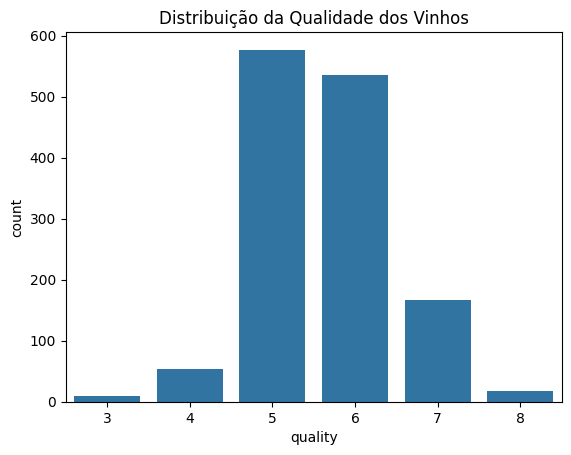

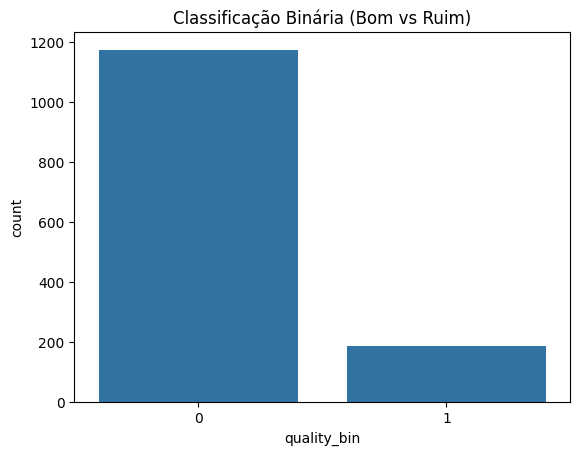

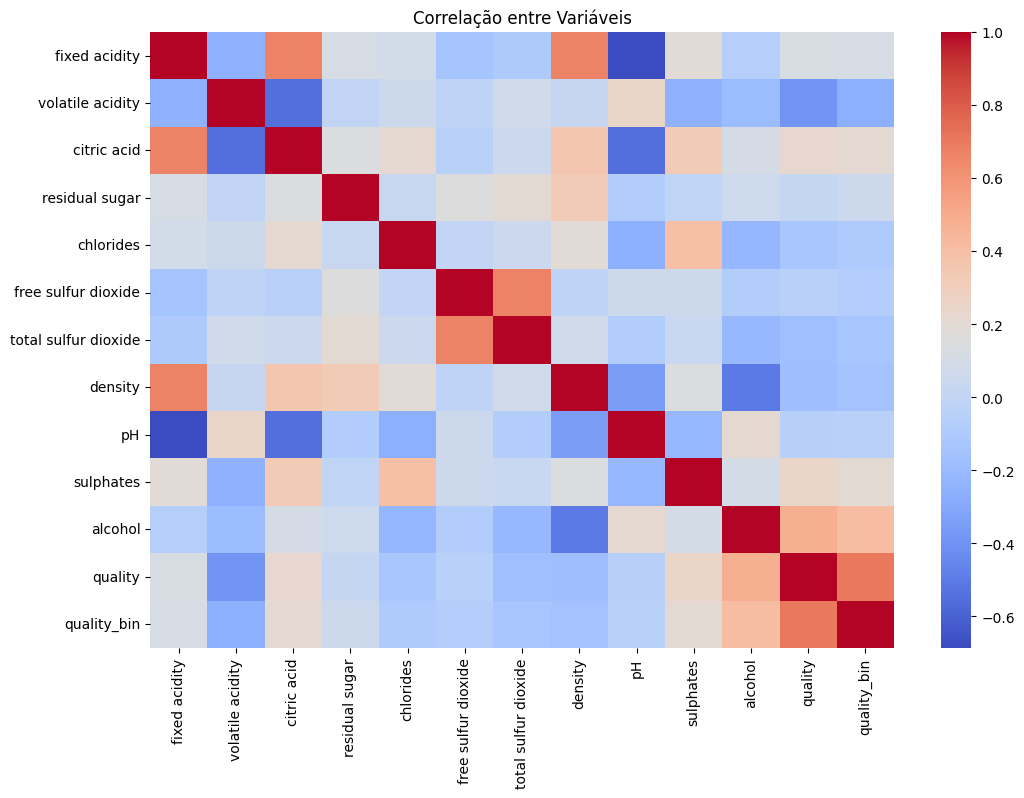

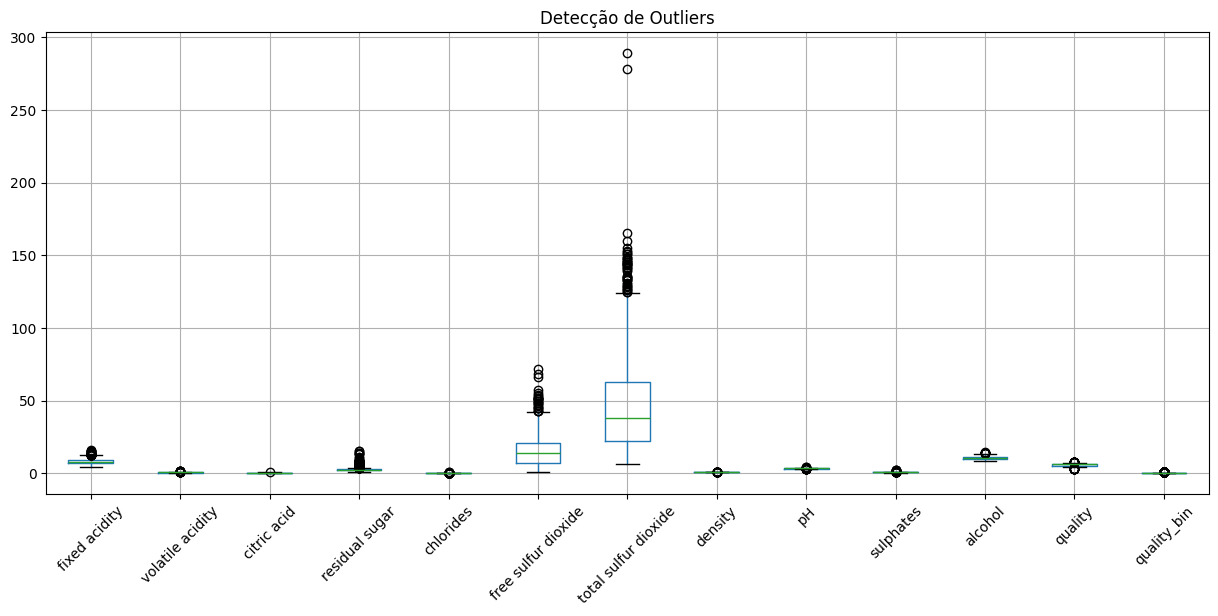

In [ ]:
sns.countplot(x='quality', data=df)   #mostra qtos vinhos existe para cada nota de qualidade
plt.title("Distribuição da Qualidade dos Vinhos")
plt.show()

# A maioria dos vinhos está concentrada nas notas 5 e 6, com poucos vinhos de alta qualidade (≥7)
df['quality_bin'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)    #criação/transformação de variáveis. lambda cria coluna 'quality_bin e separa em vinho bom >=7 (1), vinho ruim <7 (0)

sns.countplot(x='quality_bin', data=df)      #verificação de desbalanceamento
plt.title("Classificação Binária (Bom vs Ruim)")
plt.show()                                   # Observa-se desbalanceamento entre as classes, com mais vinhos classificados como "ruins"

#Matriz de correlação
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')    #transforma a matriz em mapas de cores
plt.title("Correlação entre Variáveis")
plt.show()
# alcohol apresenta correlação positiva com a qualidade
# volatile acidity apresenta correlação negativa


#gráfico boxplot
df.boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.title("Detecção de Outliers")
plt.show()
# Existem outliers em diversas variáveis, principalmente em total sulfur dioxide


# Etapa 4: Pré-Processamento e Divisão dos Dados

Antes de treinar os algoritmos, precisamos isolar as variáveis preditoras da resposta e segmentar o dataset já tratado.
* **Separação de Variáveis:** Removemos as colunas `quality` e `quality_bin` do conjunto `X` para evitar que os modelos tenham acesso direto à resposta correta durante o treino.
* **Divisão Estratificada (60% / 20% / 20%):** Separamos os dados em treino, validação e teste. Primeiro, 20% dos dados são isolados para teste final. Depois, o restante é dividido novamente, formando aproximadamente 60% para treino, 20% para validação e 20% para teste.
* **Uso do `stratify=y`:** Esse parâmetro mantém a proporção entre vinhos comuns e vinhos bons/excelentes nos conjuntos, o que é importante porque a variável-alvo é desbalanceada.
* **Nota de Correção P2:** O escalonamento (`StandardScaler`) foi intencionalmente removido desta célula e acoplado ao `Pipeline`, reduzindo o risco de *Data Leakage* da P1.


In [ ]:
X = df.drop(columns=['quality', 'quality_bin'])
y = df['quality_bin']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Divisão dos dados:")
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Divisão dos dados:
Treino: 815 amostras
Validação: 272 amostras
Teste: 272 amostras


# Etapa 5: Construção dos Pipelines, Treinamento e Validação Cruzada

Aqui executamos o coração técnico das melhorias aplicadas na P2. Em vez de treinar os modelos de forma solta, implementamos a arquitetura de **Pipelines**.

### Como funciona o fluxo de execução desta célula:
1. **Definição do Pipeline:** Cada algoritmo (**Regressão Logística, KNN e Random Forest**) é encapsulado junto com o `StandardScaler`. O Pipeline ajuda a evitar vazamento de dados: a escala aprende os parâmetros estatísticos apenas com os dados que entram no treino e aplica de forma estrita no teste.
2. **Correção do Desbalanceamento:** Adicionamos o parâmetro `class_weight='balanced'` na Regressão Logística e no Random Forest para dar um peso matemático superior à classe de vinhos excelentes (minoritária), buscando melhorar o **F1-Score Macro**.
3. **Validação Cruzada Estratificada (5-Fold CV):** O modelo é retreinado e testado ciclicamente em 5 subconjuntos diferentes dos dados. Avaliamos a média de treino e teste simultaneamente para atestar a estabilidade dos classificadores e verificar se houve redução da disparidade apontada nos feedbacks anteriores.

In [ ]:
# Criando os Pipelines estruturados (Escalonamento + Modelo)
pipe_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, class_weight='balanced'))
])

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Treinando os modelos apenas no conjunto de treino isolado
pipe_logistic.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Configurando a Validação Cruzada Estratificada em 5 partes (folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- VALIDAÇÃO CRUZADA (Comparação de F1-Score Macro) ---")
for nome, pipeline in [("Logistic Regression", pipe_logistic),
                       ("KNN", pipe_knn),
                       ("Random Forest", pipe_rf)]:

    cv_res = cross_validate(pipeline, X, y, cv=cv, scoring='f1_macro', return_train_score=True)
    print(f"\n> {nome}:")
    print(f"   F1-Score Médio no Treino (CV): {cv_res['train_score'].mean():.4f}")
    print(f"   F1-Score Médio no Teste  (CV): {cv_res['test_score'].mean():.4f}")

--- VALIDAÇÃO CRUZADA (Comparação de F1-Score Macro) ---

> Logistic Regression:
   F1-Score Médio no Treino (CV): 0.6968
   F1-Score Médio no Teste  (CV): 0.6943

> KNN:
   F1-Score Médio no Treino (CV): 0.7676
   F1-Score Médio no Teste  (CV): 0.6783

> Random Forest:
   F1-Score Médio no Treino (CV): 1.0000
   F1-Score Médio no Teste  (CV): 0.6704


# Etapa 6: Avaliação de Desempenho no Ambiente de Teste (Métricas Finais)

Com os modelos consolidados, criamos a função `avaliar_modelo` para testar os algoritmos no conjunto de dados de teste (os 20% isolados que o modelo nunca viu).
* Computamos as métricas de **Acurácia, Precisão, Recall, F1-Score e AUC-ROC**.
* Configuramos o cálculo do F1-Score utilizando a média `macro`, que atribui o mesmo peso para as duas classes de vinhos, entregando uma métrica fiel e penalizando modelos que tentem ignorar a classe minoritária. O resultado é consolidado num quadro comparativo para determinar o nosso modelo campeão.

In [ ]:
# Função para calcular de forma limpa todas as métricas no ambiente de teste
def avaliar_modelo(pipeline):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro'),
        roc_auc_score(y_test, y_prob)
    ]

# Executando a avaliação
res1 = avaliar_modelo(pipe_logistic)
res2 = avaliar_modelo(pipe_knn)
res3 = avaliar_modelo(pipe_rf)

# Construindo o DataFrame final de resultados
df_resultados = pd.DataFrame(
    [res1, res2, res3],
    columns=["Acurácia", "Precisão", "Recall", "F1-Score", "AUC-ROC"],
    index=["Logistic Regression", "KNN", "Random Forest"]
)

df_resultados

,Acurácia,Precisão,Recall,F1-Score,AUC-ROC
Logistic Regression,0.768382,0.664042,0.809028,0.676429,0.883496
KNN,0.860294,0.689393,0.634503,0.654129,0.784761
Random Forest,0.875000,0.751708,0.597470,0.625587,0.871593


# Etapa 7: Análise Visual de Erros e Acertos (Matrizes de Confusão)

A Matriz de Confusão cruza os valores reais do dataset com as previsões efetuadas pelos modelos.
* **Diagonal Principal:** Indica os acertos de vinhos comuns (superior esquerdo) e vinhos excelentes (inferior direito).
* **Diagonal Secundária:** Mapeia os erros de falsos positivos e falsos negativos.

Nesta etapa, analisamos visualmente os erros e acertos para entender o comportamento de cada classificador após a limpeza do dataset. Como a classe 1 representa vinhos bons/excelentes e é minoritária, observamos principalmente a quantidade de **falsos negativos**, ou seja, vinhos excelentes classificados incorretamente como comuns.


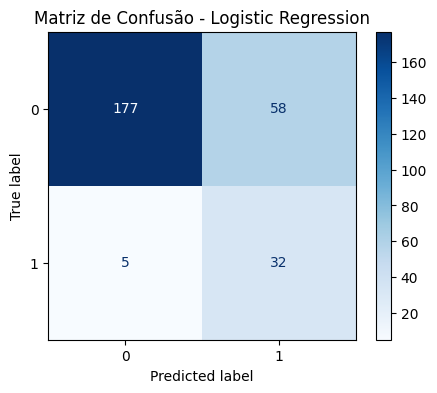

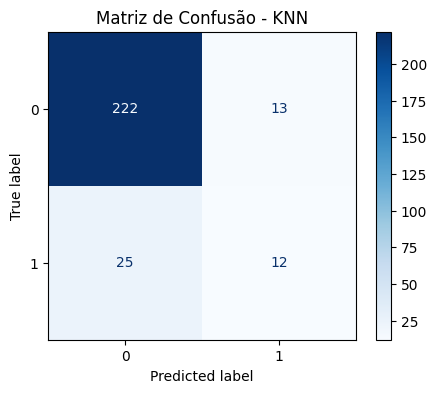

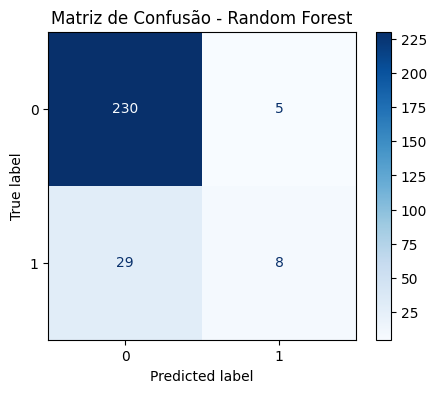

In [ ]:
# Lista de modelos para iteração dos gráficos
modelos_lista = [
    ("Logistic Regression", pipe_logistic),
    ("KNN", pipe_knn),
    ("Random Forest", pipe_rf)
]

# Plotando as Matrizes de Confusão de forma limpa
for nome, pipeline in modelos_lista:
    y_pred = pipeline.predict(X_test)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f"Matriz de Confusão - {nome}")
    plt.show()

# Etapa 8: Análise de Discriminação (Curva ROC e AUC)

A Curva ROC (Receiver Operating Characteristic) plota a Taxa de Verdadeiros Positivos contra a Taxa de Falsos Positivos para diferentes limiares de decisão.
* A linha tracejada cinzenta representa o *Baseline* (um modelo puramente aleatório).
* Quanto mais próxima a curva de um modelo estiver do canto superior esquerdo, maior é a sua área sob a curva (AUC-ROC) e melhor é a sua capacidade matemática de separar com precisão o que é um vinho bom de um vinho ruim. Utilizamos este gráfico como critério definitivo de desempate entre os classificadores.

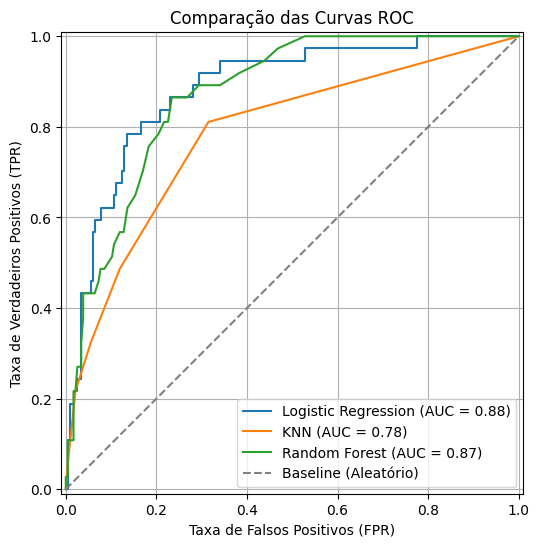

In [ ]:
# Plotando as Curvas ROC sobrepostas para comparação visual direta
plt.figure(figsize=(8, 6))
ax = plt.gca()

for nome, pipeline in modelos_lista:
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=nome)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (Aleatório)')
plt.title("Comparação das Curvas ROC")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.legend()
plt.grid(True)
plt.show()

# Etapa 9: Escolha do Modelo Final

Após a análise das métricas e das matrizes de confusão, o modelo mais indicado para este projeto foi a **Regressão Logística**.

A escolha foi feita porque o objetivo do projeto não é apenas obter a maior acurácia geral, mas identificar corretamente os vinhos bons/excelentes, representados pela classe 1. Como essa classe é minoritária, modelos que acertam muitos vinhos comuns, mas deixam de reconhecer vinhos excelentes, podem apresentar uma acurácia alta sem serem os mais adequados para o problema.

Comparando os modelos após a remoção das duplicatas:

* **Regressão Logística:** apresentou o melhor equilíbrio para a classe positiva, com menor quantidade de falsos negativos. Isso significa que foi o modelo que melhor conseguiu identificar os vinhos excelentes.
* **KNN:** manteve comportamento conservador, classificando muitos vinhos como classe 0 e deixando de identificar parte relevante dos vinhos excelentes.
* **Random Forest:** apesar de apresentar bons acertos na classe 0, passou a classificar poucos vinhos como classe 1 após a remoção das duplicatas, aumentando os falsos negativos.

Assim, a **Regressão Logística** foi escolhida como modelo final por apresentar melhor equilíbrio entre as métricas e maior capacidade de reconhecer a classe mais importante do problema. Além disso, é um modelo mais interpretável, o que facilita a explicação técnica no relatório, no notebook e no vídeo individual.


In [ ]:
# Selecionando o modelo final escolhido para o projeto
modelo_final = pipe_logistic
nome_modelo_final = "Logistic Regression"

print(f"Modelo final escolhido: {nome_modelo_final}")


Modelo final escolhido: Logistic Regression


# Etapa 10: Explicabilidade do Modelo Final

Como o modelo final escolhido foi a **Regressão Logística**, a explicabilidade foi realizada por meio dos coeficientes do modelo.

Na Regressão Logística, os coeficientes indicam a influência de cada variável na decisão do classificador. Valores positivos contribuem para aumentar a chance de o vinho ser classificado como bom/excelente, enquanto valores negativos contribuem para a classificação como vinho comum.

Como o modelo foi treinado dentro de um `Pipeline` com `StandardScaler`, os coeficientes podem ser comparados de forma mais justa, pois as variáveis foram padronizadas antes do treinamento.


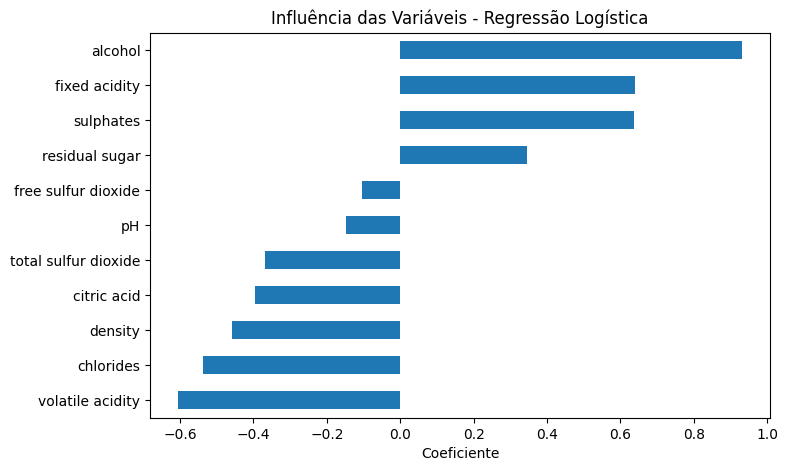

In [ ]:
# Extraindo os coeficientes da Regressão Logística dentro do Pipeline
coeficientes = modelo_final.named_steps['model'].coef_[0]
coef_series = pd.Series(coeficientes, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
coef_series.plot(kind='barh')
plt.title("Influência das Variáveis - Regressão Logística")
plt.xlabel("Coeficiente")
plt.show()


# Etapa 11: Exportação e Salvamento do Modelo Final (.pkl)

Esta etapa atende à exigência da P2 de salvar o modelo final treinado.

Utilizamos a biblioteca `joblib` para exportar o pipeline completo da **Regressão Logística**, que foi o modelo escolhido. O arquivo gerado contém tanto o `StandardScaler` quanto o modelo treinado, garantindo que a aplicação Streamlit consiga carregar o mesmo fluxo utilizado no notebook e executar novas predições sem precisar repetir o treinamento.


In [ ]:
# Exportando o pipeline completo do modelo final para arquivo binário usando joblib
joblib.dump(modelo_final, 'modelo_classificacao_vinhos.pkl')

print("SUCESSO: Arquivo 'modelo_classificacao_vinhos.pkl' gerado e pronto para o Streamlit!")


SUCESSO: Arquivo 'modelo_classificacao_vinhos.pkl' gerado e pronto para o Streamlit!


# Etapa 12: Limitações do Projeto

Apesar das melhorias aplicadas na P2, o projeto ainda possui algumas limitações importantes:

* O dataset apresenta desbalanceamento entre as classes, pois existem muito mais vinhos comuns do que vinhos bons/excelentes.
* Após a remoção das 240 duplicatas, o conjunto de dados ficou menor, o que pode reduzir um pouco as métricas, mas torna a avaliação mais honesta.
* A classificação binária simplifica a variável `quality`, agrupando notas diferentes em apenas duas classes.
* O modelo depende apenas das características físico-químicas disponíveis no dataset, sem considerar fatores externos como safra, tipo da uva, região ou avaliação sensorial.

Essas limitações não invalidam o projeto, mas ajudam a interpretar os resultados de forma mais realista e técnica.


### MELHORIAS DA P1 PARA A P2: Correção de Overfitting, Data Leakage e Rebalanceamento de Classes

Com base nos feedbacks e na devolutiva da P1, identificamos três pontos críticos que precisavam ser corrigidos e evoluídos para a P2:
1. **Diferença acentuada entre as métricas de Treino e Teste:** Forte indício de Overfitting e Vazamento de Dados (*Data Leakage*).
2. **Resultados fracos de F1-Score:** Causados pelo severo desbalanceamento na variável alvo (`quality_bin`), onde havia uma quantidade massiva de vinhos comuns/ruins (Classe 0) e pouquíssimos vinhos excelentes (Classe 1).
3. **Ausência de validação robusta e artefatos visuais obrigatórios:** Necessidade de implementar validação cruzada, matrizes de confusão e curvas ROC.

---

#### Soluções Implementadas no Código:

#### 1. Rebalanceamento Algorítmico de Classes (`class_weight='balanced'`)
Para solucionar o problema do F1-Score baixo sem a necessidade de criar dados sintéticos artificiais ou descartar registros reais, ativamos o parâmetro de balanceamento diretamente nos modelos de Machine Learning (Regressão Logística e Random Forest).
* **Como funciona:** O algoritmo calcula pesos inversamente proporcionais às frequências das classes. Como a classe de vinhos excelentes é minoritária, o modelo passa a receber uma "penalidade matemática" muito maior toda vez que erra um vinho bom. Isso força o modelo a aprender as características reais de vinhos de alta qualidade, buscando melhorar a identificação da classe minoritária e, consequentemente, o **F1-Score Macro**.

#### 2. Blindagem contra Data Leakage via `Pipeline`
No fluxo anterior, a padronização dos dados (`StandardScaler`) era aplicada no dataset inteiro antes da divisão de treino e teste. Isso fazia com que informações estatísticas do teste (como média e desvio padrão) "vazassem" para o treinamento, gerando métricas falsamente infladas no treino e discrepantes no teste.
* **Como funciona:** Estruturamos todo o fluxo utilizando o objeto `Pipeline` do Scikit-Learn. O Pipeline garante o isolamento absoluto: o escalonamento aprende os parâmetros (`.fit()`) exclusivamente com os dados de treino e apenas aplica a transformação (`.transform()`) nos dados de teste.

#### 3. Novo Treinamento Estratificado e Validação Cruzada (`StratifiedKFold`)
Substituímos o treinamento simples por uma rotina de Validação Cruzada Estratificada em 5 dobras (*5-Fold Cross-Validation*).
* **Como funciona:** O modelo agora é retreinado do zero 5 vezes consecutivas. A cada rodada, o dataset de treino é dividido em 5 partes, onde 4 são usadas para treinar e 1 para validar, alternando-as ciclicamente. A presença do termo *Stratified* garante que cada uma dessas 5 subdivisões mantenha exatamente a mesma proporção original entre vinhos bons e ruins.

Com essas implementações, garantimos um modelo estatisticamente confiável, robusto contra novos dados e pronto para ser exportado e consumido pela nossa aplicação web no Streamlit.